# Notebook for setting up and prcoessing the RHINO calibration Gibbs Sampler

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sampler.reader import ObservationReader, ReflectionReader

## Set up observation and reflections

In [3]:
observation = ObservationReader('simulated_data/sim_data.hdf5')
print(np.unique(observation.states_array))

reflection_dict = {'antenna':'simulated_data/antenna_gamma_src.s2p',
                   'heated_load':"simulated_data/heated_load_gamma_src.s2p",
                   'internal_load':'simulated_data/internal_load_gamma_src.s2p',
                   'long_open':'simulated_data/long_open_gamma_src.s2p',
                   'long_short':'simulated_data/long_short_gamma_src.s2p',
                   'open':'simulated_data/open_gamma_src.s2p',
                   'short':'simulated_data/short_gamma_src.s2p',
                   'receiver':'simulated_data/gamma_rec.s2p'}

reflections = ReflectionReader(component_dict=reflection_dict,
                               output_frequencies=observation.freqs,
                               polynomial_interp=True,
                               polynomial_fitting_order=10)

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampl

In [4]:
from sampler.linear_basis import BasisConstructor

## Set up basis functions

In [ ]:
gains_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=5,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

unc_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=5,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

cos_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=5,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

sin_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=5,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

rx_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=2,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

ambient_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

heated_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

antenna_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=5,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

## Construct Operators

In [6]:
from sampler.operator_setup import generate_noise_wave_transfer_matrix
from sampler.operator_setup import generate_non_smooth_source_matrix, generate_smooth_source_matrix, generate_noise_wave_transfer_matrix
# Noise Wave Operator
X_noise_wave, nw_index_dict = generate_noise_wave_transfer_matrix(observation,
                                                               reflections,
                                                               unc_basis,
                                                               cos_basis,
                                                               sin_basis,
                                                               rx_basis)
print(nw_index_dict)
print(X_noise_wave.shape)


{'unc': (0, 5), 'cos': (5, 10), 'sin': (10, 15), 'rx': (15, 20)}
(1474560, 20)


## Construct Antenna Operator

In [7]:
X_antenna = generate_smooth_source_matrix(observation,
                                          reflections,
                                          source_basis=antenna_basis,
                                          source_label='antenna')

print(X_antenna.shape)

(1474560, 5)


### Combine Noisewave and Antenna Operators

In [8]:


X_ant_noisewave = np.concatenate((X_antenna, X_noise_wave), axis=1)


## Construct Calibration Source Operator

In [9]:
print(np.unique(observation.switch_states))

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


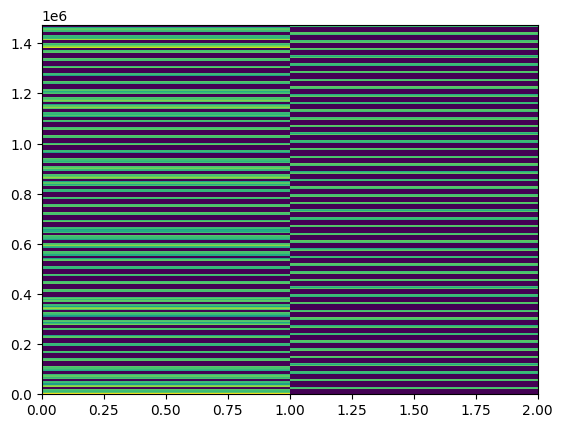

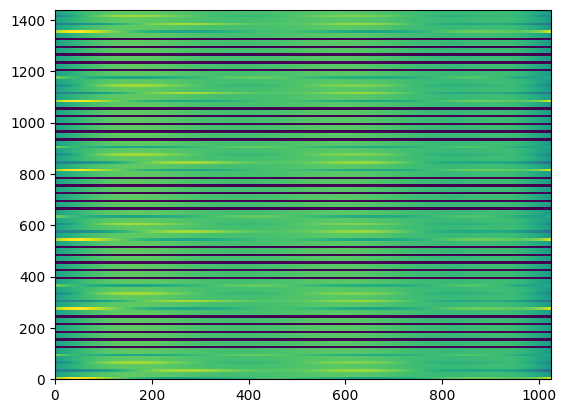

In [10]:
X_ambient = generate_smooth_source_matrix(observation, reflections,
                                          source_basis=ambient_basis,
                                          source_label=['internal_load', 'long_open',
                                                        'long_short', 'open', 'short'])
X_heated = generate_smooth_source_matrix(observation, reflections,
                                         source_basis=heated_basis,
                                         source_label='heated_load')

X_calibrator = np.concatenate((X_ambient, X_heated), axis=1)
plt.pcolormesh(X_calibrator)
plt.show()
cont = X_calibrator @ np.ones_like(X_calibrator[0])
cont = np.reshape(cont, shape=observation.data_waterfall.shape)
plt.pcolormesh(cont)
plt.show()

### Construct Cal Source Priors

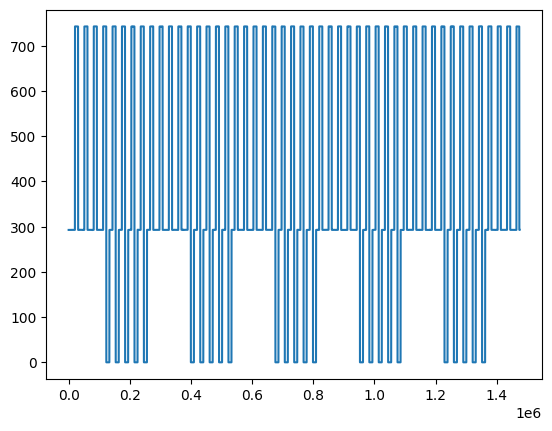

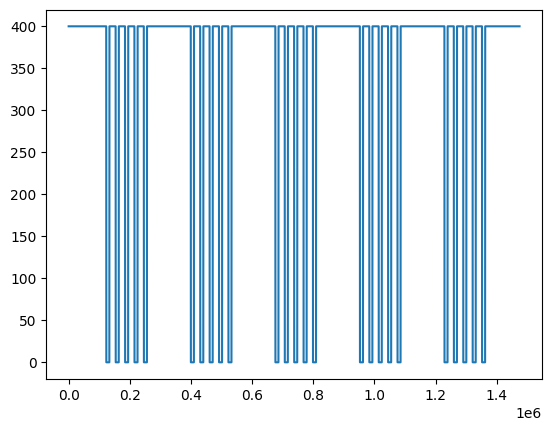

In [11]:
from sampler.priors import setup_probe_cal_priors
cal_source_priors, cal_source_prior_inv_cov = setup_probe_cal_priors(observation,
                                           source_temp_dict={'heated':'heated_load',
                                                             'ambient':['internal_load',
                                                                        'open',
                                                                        'short',
                                                                        'long_open',
                                                                        'long_short']},
                                                                        temp_std=0.05)

plt.plot(cal_source_priors)
plt.show()
plt.plot(cal_source_prior_inv_cov)
plt.show()

In [12]:
### Attempt a Weiner solution fit

from sampler.gibbs_sample import construct_gcr_lhs, construct_gcr_rhs, solve_gcr

cal_source_lhs = construct_gcr_lhs(linear_operator=X_calibrator,
                                   inv_data_cov=cal_source_prior_inv_cov,
                                   inv_prior_cov=cal_source_prior_inv_cov)
cal_source_rhs = construct_gcr_rhs(linear_operator=X_calibrator,
                                   data=cal_source_priors,
                                   inv_data_cov=cal_source_prior_inv_cov,
                                   omega_data=np.zeros_like(observation.data_waterfall.flatten()),
                                   priors=cal_source_priors,
                                   inv_prior_cov=cal_source_prior_inv_cov,
                                   weiner_solution=True)

init_calibrator_solution = solve_gcr(cal_source_lhs, cal_source_rhs)

# ambient_amps, heated_amps = init_calibrator_solution[:4], init_calibrator_solution[4:]
# print(ambient_amps)
# print(heated_amps)

# reconstructed_ambient = ambient_basis.basis_matrix @ ambient_amps
# reconstructed_heated = ambient_basis.basis_matrix @ heated_amps

# plt.pcolormesh(np.reshape(reconstructed_ambient, shape=observation.data_waterfall.shape))
# plt.colorbar()
# plt.show()

# plt.pcolormesh(np.reshape(reconstructed_heated, shape=observation.data_waterfall.shape))
# plt.colorbar()
# plt.show()

## Gain Operator

In [13]:
U_gain = gains_basis.basis_matrix
print(U_gain.shape)
# plt.pcolormesh(U_gain)
# plt.show()

(1474560, 5)


In [29]:
print(observation.temperatures)

{'heated': array([743.1191679 , 742.98181535, 742.84366302, ..., 743.00481731,
       742.82859666, 742.78133454], shape=(1440,)), 'ambient': array([292.87800968, 293.08967306, 292.89288136, ..., 292.97408165,
       292.78128537, 293.01846653], shape=(1440,))}


In [43]:
# get an initial guess of the gains params

def init_gain_guess(observation_obj: ObservationReader,
                    reflections_obj: ReflectionReader,
                    gains_basis: BasisConstructor,
                    noise_source_label: str = "heated_load",
                    load_label: str = 'internal_load',
                    noise_source_temp: int | None = None):

    noise_source_mask = (observation_obj.states_array == noise_source_label)
    load_mask = (observation_obj.states_array == load_label)
    p_ns = observation_obj.data_waterfall[noise_source_mask].mean(axis=0)
    p_l = observation_obj.data_waterfall[load_mask].mean(axis=0)

    if noise_source_temp is not None: t_ns = noise_source_temp
    else:
        t_ns = np.mean(observation_obj.temperatures['heated'])
    t_l = np.mean(observation_obj.temperatures['ambient'])

    gamma_rec = reflections_obj.s11_dict['receiver']

    mean_gain = (p_ns - p_l) / ((t_ns - t_l) * (1 - np.power(np.abs(gamma_rec), 2)))

    fitting_gain = np.zeros_like(observation.data_waterfall)
    fitting_gain[:,:] = mean_gain
    fitting_gain = fitting_gain.flatten()
    init_amp_guess = np.linalg.lstsq(gains_basis.basis_matrix, fitting_gain)[0]

    return init_amp_guess

init_gain_amps = init_gain_guess(observation, reflections, gains_basis)

# Set up Gibbs Sampler

In [14]:
from sampler.gibbs_sample import sample_loop

In [44]:
param_dict = sample_loop(data=observation.data_waterfall.flatten(),
                         N=observation.Nw.flatten(),
                         U_gain=U_gain,
                         X_ant_nw=X_ant_noisewave,
                         X_cal_src=X_calibrator,
                         init_gain_amps=init_gain_amps,
                         init_cal_src_amps=init_calibrator_solution,
                         init_ant_nw_amps=np.ones_like(X_ant_noisewave[0]),
                         cal_src_priors=cal_source_priors,
                         inv_cal_src_prior_cov=cal_source_prior_inv_cov, n_iter=200,
                         verbose=True)

d_cont  [424.58991475 429.79486206 429.04335119 ... 551.5429531  567.08007901
 575.62175413]
inv_cont_cov  [0.00079932 0.00078574 0.00077264 ... 0.0003956  0.00038899 0.00038236]
p_ant_nw - 0
[   14763.17685087   -18793.81792591    13933.6995641    -30110.35325754
    22671.83338844   125533.44079658  -423623.11002032   533714.57236895
  -297586.91213442    61983.72166825   175645.62050556  -635319.30449507
   858852.86518303  -514265.90316412   115100.74309813    -5915.30016013
    44774.30877156   -90323.25988368    70801.38151468   -19311.79097891
   716953.62171862 -2502185.73136589  3267923.35269534 -1892817.18528645
   410577.31432865]
d_gain  [373.34000843 377.38221928 378.54242944 ...  68.46640965  68.03734759
  66.97146914]
d_gain_inv_cov  [0.00061445 0.00061216 0.00060989 ... 0.0254659  0.02661439 0.02784691]
p_gain - 0
[ -277724.50304456   978507.63687971 -1299185.27828173   768853.29760815
  -170384.78162177]
d_cont  [299.41772548 309.25690705 313.20401298 ... 247.9359718  

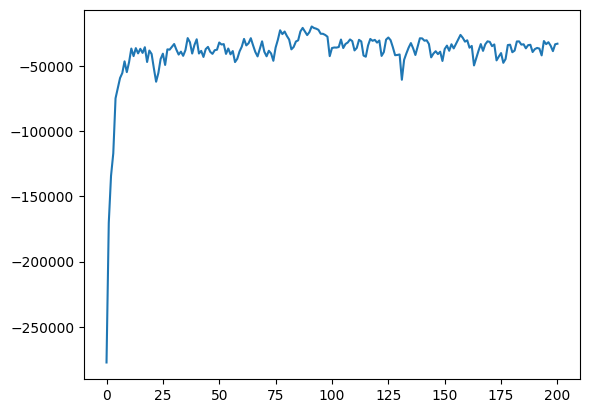

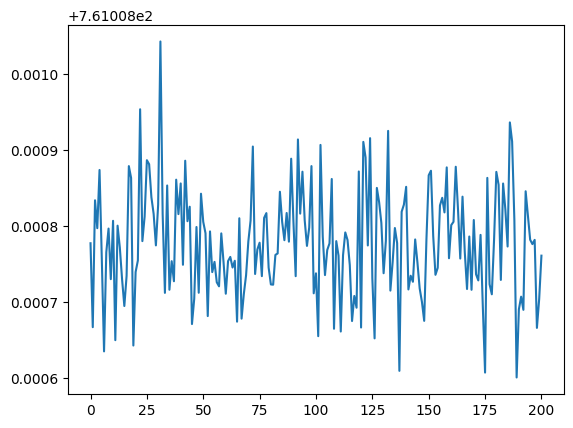

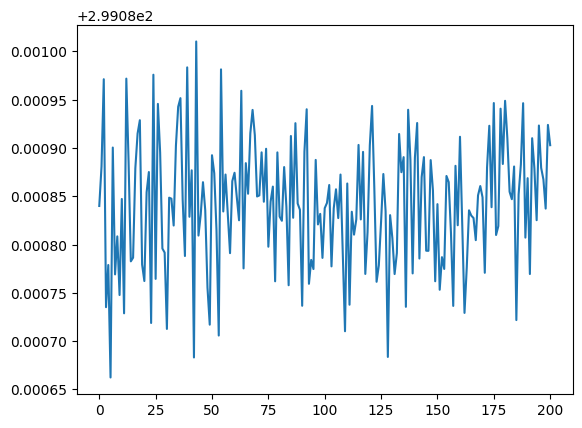

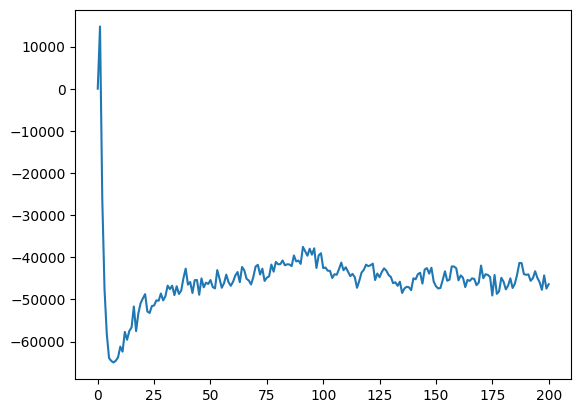

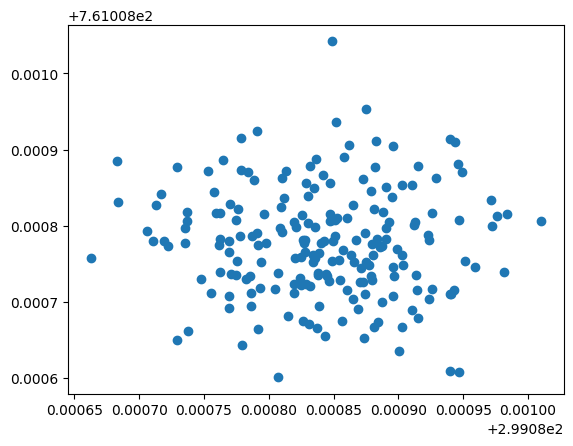

In [45]:
plt.plot(param_dict['all_p_gain'][:,-1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, -1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, 0])
plt.show()
plt.plot(param_dict['all_p_ant_nw'][:, 0])
plt.show()

plt.scatter(param_dict['all_p_cal_src'][:, 0], param_dict['all_p_cal_src'][:, 1])
plt.show()

In [48]:
param_dict = sample_loop(data=observation.data_waterfall.flatten(),
                         N=observation.Nw.flatten(),
                         U_gain=U_gain,
                         X_ant_nw=X_ant_noisewave,
                         X_cal_src=X_calibrator,
                         init_gain_amps=np.median(param_dict['all_p_gain'], axis=0),
                         init_cal_src_amps=init_calibrator_solution,
                         init_ant_nw_amps=np.median(param_dict['all_p_ant_nw'], axis=0),
                         cal_src_priors=cal_source_priors,
                         inv_cal_src_prior_cov=cal_source_prior_inv_cov, n_iter=500,
                         verbose=False)

Gibbs Sample - 0 / 500
Gibbs Sample - 50 / 500
Gibbs Sample - 100 / 500
Gibbs Sample - 150 / 500
Gibbs Sample - 200 / 500
Gibbs Sample - 250 / 500
Gibbs Sample - 300 / 500
Gibbs Sample - 350 / 500
Gibbs Sample - 400 / 500
Gibbs Sample - 450 / 500


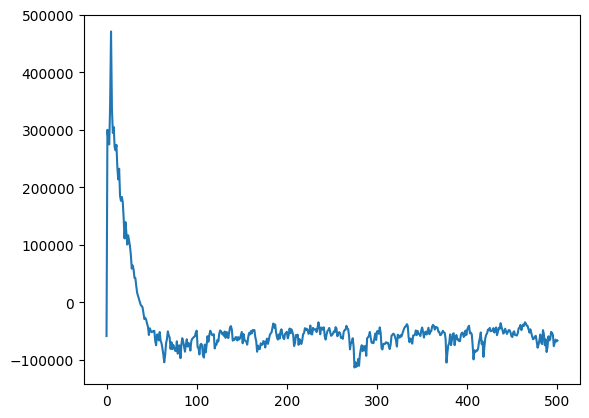

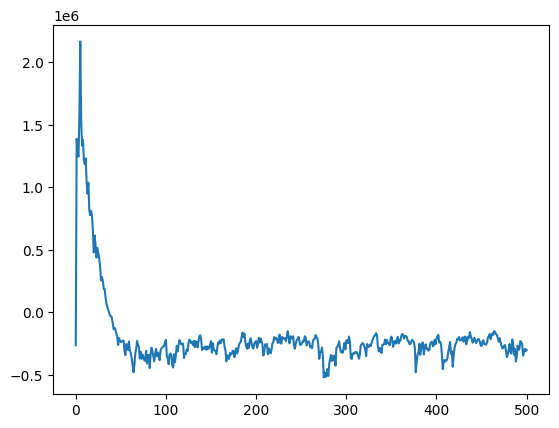

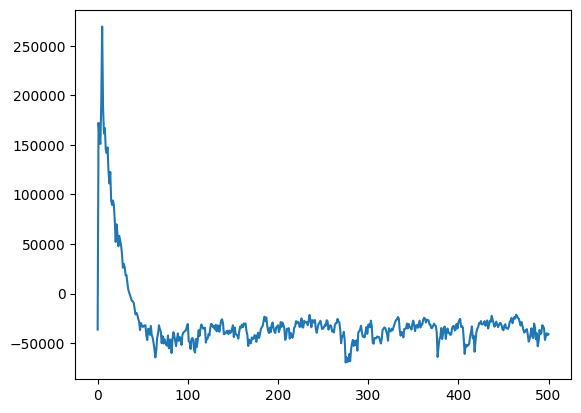

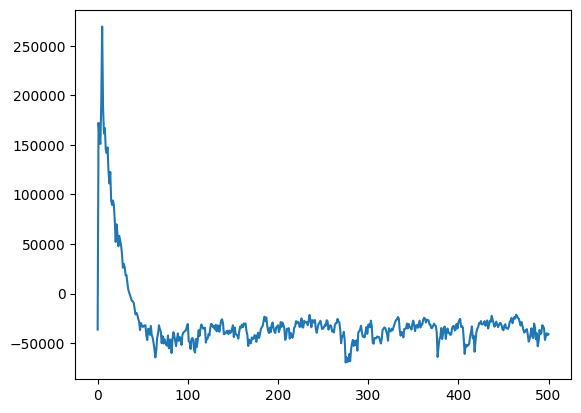

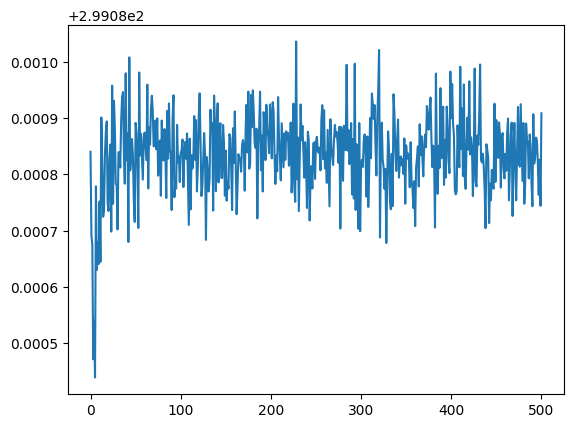

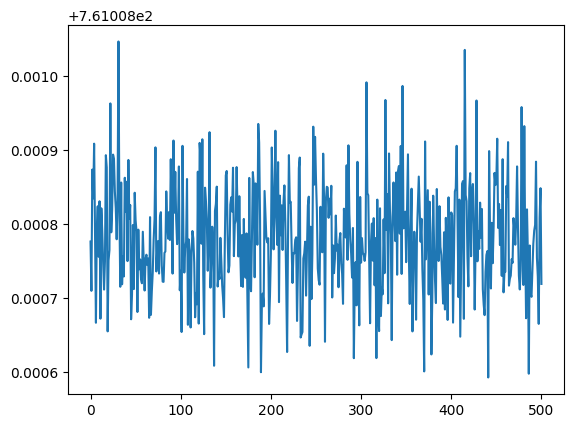

761.0087793764512


In [49]:
plt.plot(param_dict['all_p_gain'][:,0])
plt.show()
plt.plot(param_dict['all_p_gain'][:,2])
plt.show()
plt.plot(param_dict['all_p_gain'][:,4])
plt.show()
plt.plot(param_dict['all_p_gain'][:,-1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, 0])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, -1])
plt.show()


print(np.median(param_dict['all_p_cal_src'][:, -1]))





[  -33854.48059844   129555.48323374  -184152.9666096    114740.77425372
   -26588.31802704   -82165.32584289   277524.3476606   -349301.62036768
   194027.55687708   -40087.92915011     7144.14427528   -14868.85791288
     5544.81674753     5213.36002568    -2981.35423476  -264381.41895013
   920036.99129808 -1196637.97558165   693380.82749585  -149348.08603031]


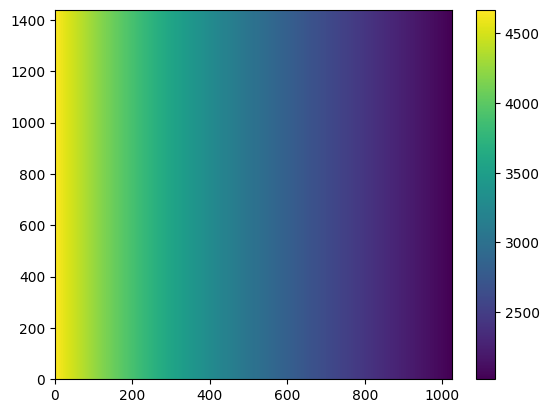

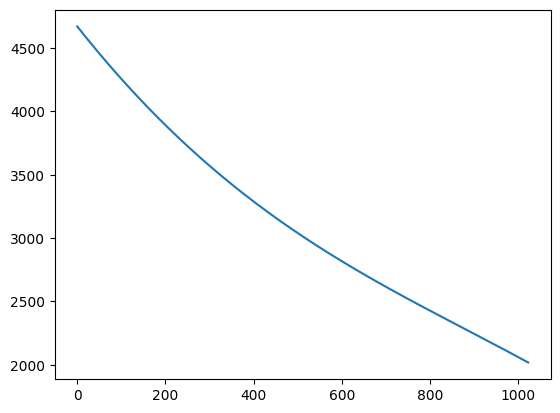

In [50]:
# Recovered Antenna

median_p_ant_nw = np.median(param_dict['all_p_ant_nw'], axis=0)
median_p_ant = median_p_ant_nw[:len(X_antenna[0])]
median_p_nw = median_p_ant_nw[len(X_antenna[0]):]
print(median_p_nw)


reconstructed_antenna = antenna_basis.basis_matrix @ median_p_ant
reconstructed_antenna = np.reshape(reconstructed_antenna, shape=observation.data_waterfall.shape)

plt.pcolormesh(reconstructed_antenna)
plt.colorbar()
plt.show()

plt.plot(reconstructed_antenna.mean(axis=0))
plt.show()

[ -56018.4709181   191936.67368238 -254929.13993737  154165.22259494
  -34983.37422932]


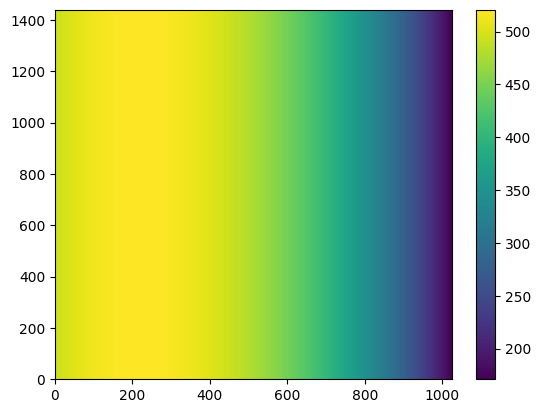

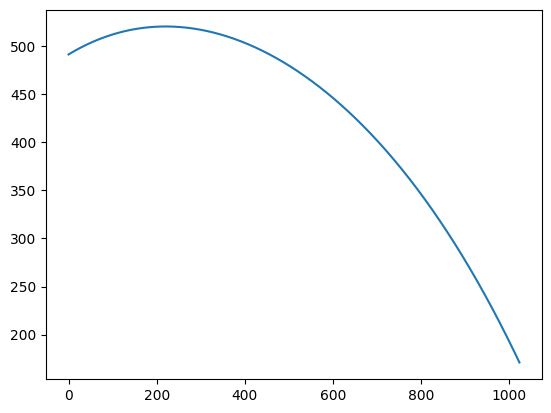

In [51]:
median_gains = np.median(param_dict['all_p_gain'], axis=0)

print(median_gains)

reconstructed_gains = gains_basis.basis_matrix @ median_gains

reconstructed_gains = np.reshape(reconstructed_gains, shape=observation.data_waterfall.shape)

plt.pcolormesh(reconstructed_gains)
plt.colorbar()
plt.show()

plt.plot(np.mean(reconstructed_gains, axis=0))
plt.show()

In [21]:
a = np.ones(shape=(5,))
b = np.zeros_like(a)

c = np.vstack((a,b))
print(c.shape)
print(c[0])

(2, 5)
[1. 1. 1. 1. 1.]


In [22]:
gains_operator[0]

dummy_gain_amps = np.zeros_like(gains_operator[0])

print(dummy_gain_amps)


print(gains_operator @ dummy_gain_amps)

NameError: name 'gains_operator' is not defined

In [ ]:
import h5py
sim_filepath = 'simulated_data/sim_data.hdf5_sim'
with h5py.File(sim_filepath) as f:
    t_unc_sim = f['t_unc'][()]
    t_sin_sim = f['t_sin'][()]
    t_cos_sim = f['t_cos'][()]